# Step 1: Loading Libraries


In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

#Step 2: Loading the Datasets

In [2]:
census = gpd.read_file("/content/drive/MyDrive/CS896/PLACES__Census_Tract_Data_(GIS_Friendly_Format).csv")
health = pd.read_csv("/content/drive/MyDrive/CS896/PLACES__Local_Data_for_Better_Health,_Census_Tract_Data.csv")
#health = pd.read_csv("/content/drive/MyDrive/CS896/PLACES__Local_Data_for_Better_Health,_Census_Tract_Data.csv", engine='python', on_bad_lines='warn')
zcta = gpd.read_file("/content/drive/MyDrive/CS896/PLACES__ZCTA_Data_(GIS_Friendly_Format).csv")
parcels = gpd.read_file("/content/drive/MyDrive/CS896/PLACES__Local_Data_for_Better_Health,_Place_Data.csv")

#Week 3

###Selecting Important Columns

In [3]:
selected_cols = [
    "TractFIPS",
    "TotalPopulation",
    "OBESITY_CrudePrev",
    "DIABETES_CrudePrev",
    "BPHIGH_CrudePrev",
    "STROKE_CrudePrev",
    "LPA_CrudePrev",
    "CSMOKING_CrudePrev",
    "ACCESS2_CrudePrev"
]

tract_data = census[selected_cols].copy()


In [4]:
print(tract_data.head())
print(tract_data.shape)

     TractFIPS TotalPopulation OBESITY_CrudePrev DIABETES_CrudePrev  \
0  01001020100            1912              38.7               11.0   
1  01001020200            2170              45.0               13.7   
2  01001020300            3373              39.4               11.5   
3  01001020400            4386              34.8               10.3   
4  01001020500           10766              36.3                8.9   

  BPHIGH_CrudePrev STROKE_CrudePrev LPA_CrudePrev CSMOKING_CrudePrev  \
0             37.7              3.0          29.6               18.0   
1             42.2              3.6          35.3               20.6   
2             38.5              3.3          31.5               18.7   
3             38.3              3.1          25.7               13.5   
4             33.7              2.4          24.7               14.3   

  ACCESS2_CrudePrev  
0              10.2  
1              13.7  
2              11.4  
3               7.9  
4               8.4  
(72337, 

##Cleaning & Converting to Numeric

In [5]:
# Converting numeric columns
numeric_cols = tract_data.columns.drop("TractFIPS")

tract_data[numeric_cols] = tract_data[numeric_cols].apply(
    pd.to_numeric, errors="coerce"
)

# Checking missing values
print(tract_data.isna().sum())


TractFIPS                0
TotalPopulation          0
OBESITY_CrudePrev     4165
DIABETES_CrudePrev    4165
BPHIGH_CrudePrev      4165
STROKE_CrudePrev      4165
LPA_CrudePrev         4165
CSMOKING_CrudePrev    4165
ACCESS2_CrudePrev     4165
dtype: int64


In [6]:
#deleting missing values
tract_data = tract_data.dropna()


In [7]:
tract_data.describe()

,TotalPopulation,OBESITY_CrudePrev,DIABETES_CrudePrev,BPHIGH_CrudePrev,STROKE_CrudePrev,LPA_CrudePrev,CSMOKING_CrudePrev,ACCESS2_CrudePrev
count,68172.000000,68172.000000,68172.000000,68172.000000,68172.000000,68172.000000,68172.000000,68172.000000
mean,4253.095948,34.343782,10.947423,32.099337,3.126735,25.220566,16.480840,11.393939
std,1915.707768,7.052591,3.743231,7.217030,1.065385,8.087518,5.949811,7.575976
min,56.000000,12.600000,0.700000,4.800000,0.300000,7.400000,3.000000,1.500000
25%,2908.000000,29.500000,8.400000,27.300000,2.400000,19.100000,12.100000,6.400000
50%,4010.000000,34.500000,10.300000,31.600000,3.000000,24.300000,15.900000,9.100000
75%,5318.000000,39.000000,12.800000,36.400000,3.600000,30.200000,20.100000,14.000000
max,37452.000000,62.100000,46.100000,73.300000,17.400000,63.900000,51.700000,65.100000


##Correlation Analysis

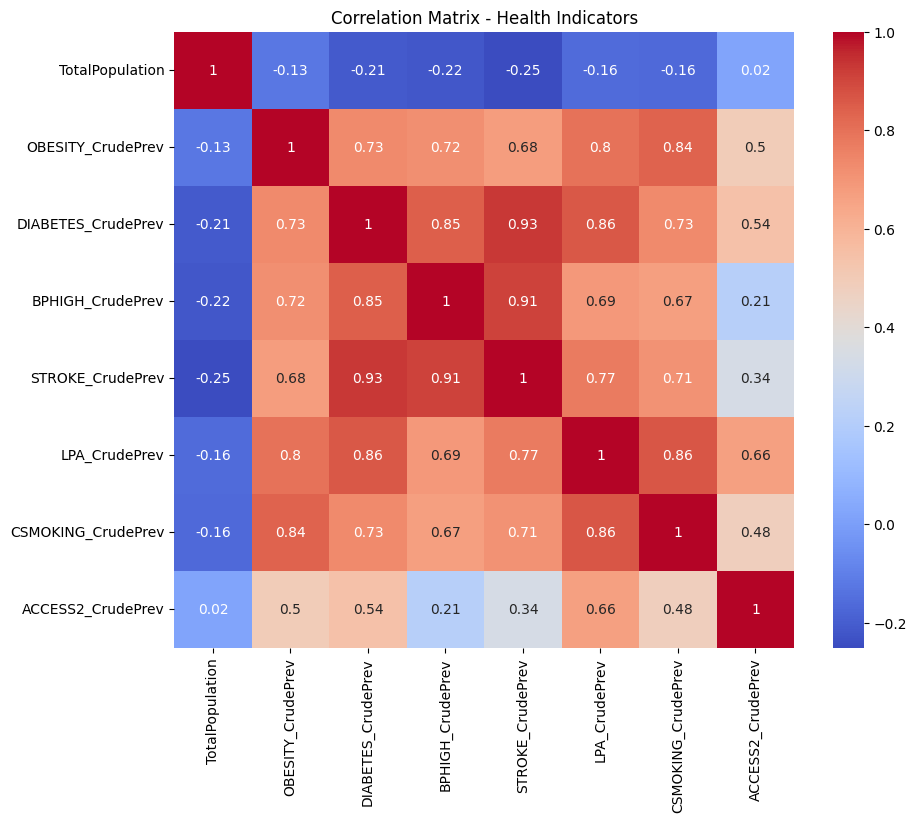

In [8]:
#Week 4
corr_matrix = tract_data[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix - Health Indicators")
plt.show()

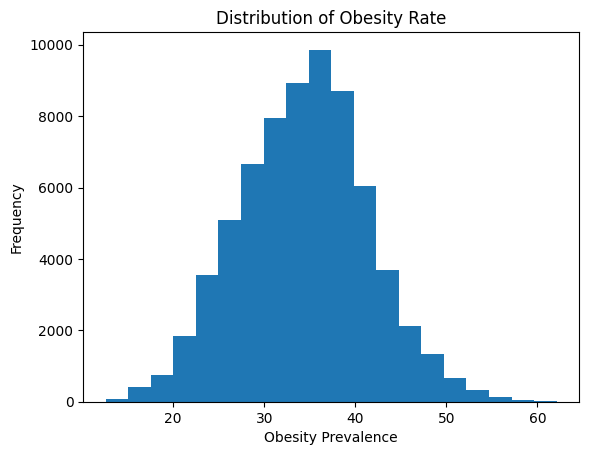

In [9]:
plt.hist(tract_data["OBESITY_CrudePrev"], bins=20)
plt.title("Distribution of Obesity Rate")
plt.xlabel("Obesity Prevalence")
plt.ylabel("Frequency")
plt.show()


##Normalizing Variables (Min-Max Scaling)

In [10]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_values = scaler.fit_transform(
    tract_data[numeric_cols]
)

scaled_df = pd.DataFrame(
    scaled_values,
    columns=numeric_cols
)

scaled_df["TractFIPS"] = tract_data["TractFIPS"].values


##Creating Vulnerability Score

In [11]:
scaled_df["VulnerabilityScore"] = (
    scaled_df["OBESITY_CrudePrev"] +
    scaled_df["DIABETES_CrudePrev"] +
    scaled_df["BPHIGH_CrudePrev"] +
    scaled_df["STROKE_CrudePrev"] +
    scaled_df["LPA_CrudePrev"] +
    scaled_df["CSMOKING_CrudePrev"] +
    scaled_df["ACCESS2_CrudePrev"]
) / 7

In [12]:
scaled_df = scaled_df.sort_values(
    by="VulnerabilityScore",
    ascending=False
)

scaled_df[["TractFIPS", "VulnerabilityScore"]].head(10)

,TractFIPS,VulnerabilityScore
42003,36081042600,0.779131
30681,26163553400,0.726387
754,01097000402,0.722848
46286,39035112100,0.700490
54959,45079010806,0.699672
42194,39035113101,0.695213
56528,47157011200,0.692622
32470,28047000100,0.689816
60203,48245006100,0.688611
55838,47065001600,0.687270


##Checking for Duplicate Values

In [13]:
# Checks full duplicate rows
print("Duplicate rows:", tract_data.duplicated().sum())


Duplicate rows: 0


In [14]:
print("Duplicate TractFIPS:", tract_data["TractFIPS"].duplicated().sum())


Duplicate TractFIPS: 0


##Checking Missing Values

In [15]:
missing = tract_data.isna().sum()
print(missing)


TractFIPS             0
TotalPopulation       0
OBESITY_CrudePrev     0
DIABETES_CrudePrev    0
BPHIGH_CrudePrev      0
STROKE_CrudePrev      0
LPA_CrudePrev         0
CSMOKING_CrudePrev    0
ACCESS2_CrudePrev     0
dtype: int64


In [16]:
missing_percent = (tract_data.isna().sum() / len(tract_data)) * 100
print(missing_percent)


TractFIPS             0.0
TotalPopulation       0.0
OBESITY_CrudePrev     0.0
DIABETES_CrudePrev    0.0
BPHIGH_CrudePrev      0.0
STROKE_CrudePrev      0.0
LPA_CrudePrev         0.0
CSMOKING_CrudePrev    0.0
ACCESS2_CrudePrev     0.0
dtype: float64


#Week 4

In [17]:
weights = {
    "OBESITY_CrudePrev": 0.2,
    "DIABETES_CrudePrev": 0.2,
    "LPA_CrudePrev": 0.2,
    "BPHIGH_CrudePrev": 0.15,
    "STROKE_CrudePrev": 0.15,
    "ACCESS2_CrudePrev": 0.1
}

In [18]:
scaled_df["SuitabilityScore"] = (
    scaled_df["OBESITY_CrudePrev"] * weights["OBESITY_CrudePrev"] +
    scaled_df["DIABETES_CrudePrev"] * weights["DIABETES_CrudePrev"] +
    scaled_df["LPA_CrudePrev"] * weights["LPA_CrudePrev"] +
    scaled_df["BPHIGH_CrudePrev"] * weights["BPHIGH_CrudePrev"] +
    scaled_df["STROKE_CrudePrev"] * weights["STROKE_CrudePrev"] +
    scaled_df["ACCESS2_CrudePrev"] * weights["ACCESS2_CrudePrev"]
)

In [19]:
scaled_df = scaled_df.sort_values(
    by="SuitabilityScore",
    ascending=False
)

scaled_df[["TractFIPS", "SuitabilityScore"]].head(10)


,TractFIPS,SuitabilityScore
42003,36081042600,0.857306
754,01097000402,0.796207
30681,26163553400,0.756191
46286,39035112100,0.746069
42194,39035113101,0.737050
32526,28049001100,0.725951
55838,47065001600,0.720766
60203,48245006100,0.720072
885,01101001200,0.715605
56528,47157011200,0.709609


In [68]:
location_tract_mapping = health[['LocationID', 'TractFIPS']].drop_duplicates()

parcels_with_tract = parcels.merge(
    location_tract_mapping,
    on='LocationID',
    how='left'
)

parcel_master = parcels_with_tract.merge(
    tract_data,
    on='TractFIPS',
    how='left'
)

KeyError: "['TractFIPS'] not in index"

## Recalculating Suitability Score for Spatially Joined Parcels

In [72]:
#includes Week 5
weights = {
    "OBESITY_CrudePrev": 0.2,
    "DIABETES_CrudePrev": 0.2,
    "LPA_CrudePrev": 0.2,
    "BPHIGH_CrudePrev": 0.15,
    "STROKE_CrudePrev": 0.15,
    "ACCESS2_CrudePrev": 0.1
}

parcels_joined_nearest["SuitabilityScore"] = (
    parcels_joined_nearest["OBESITY_CrudePrev"] * weights["OBESITY_CrudePrev"] +
    parcels_joined_nearest["DIABETES_CrudePrev"] * weights["DIABETES_CrudePrev"] +
    parcels_joined_nearest["LPA_CrudePrev"] * weights["LPA_CrudePrev"] +
    parcels_joined_nearest["BPHIGH_CrudePrev"] * weights["BPHIGH_CrudePrev"] +
    parcels_joined_nearest["STROKE_CrudePrev"] * weights["STROKE_CrudePrev"] +
    parcels_joined_nearest["ACCESS2_CrudePrev"] * weights["ACCESS2_CrudePrev"]
)

print("Head of parcels_joined_nearest with SuitabilityScore:")
print(parcels_joined_nearest[['LocationID', 'SuitabilityScore']].head())

Head of parcels_joined_nearest with SuitabilityScore:
  LocationID  SuitabilityScore
0    2978838            19.310
1    2978928            24.845
2    2979054            16.840
3    5526175            21.165
4    2979558            22.925


## Visualizing the Distribution of Suitability Score

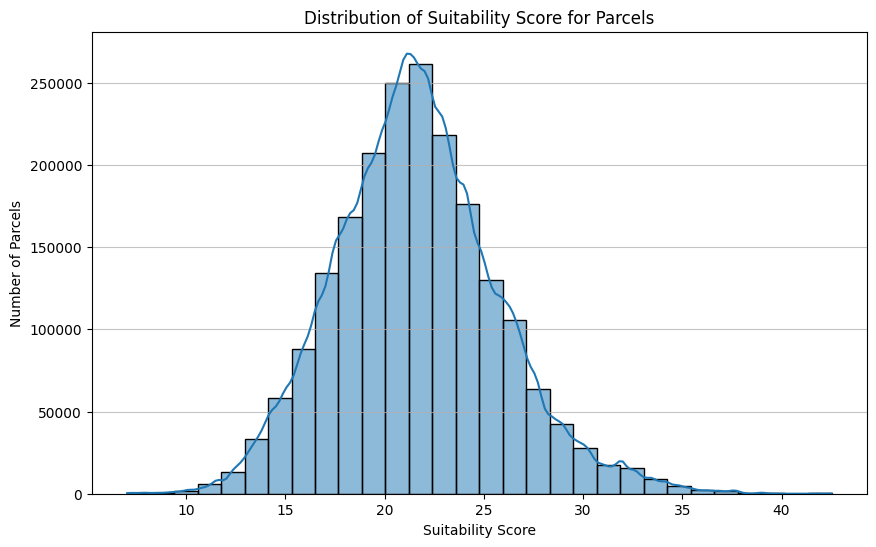

In [57]:
plt.figure(figsize=(10, 6))
sns.histplot(parcels_joined_nearest["SuitabilityScore"], bins=30, kde=True)
plt.title("Distribution of Suitability Score for Parcels")
plt.xlabel("Suitability Score")
plt.ylabel("Number of Parcels")
plt.grid(axis='y', alpha=0.75)
plt.show()

## Top Parcels by Suitability Score

In [58]:
print("Top 10 Parcels with Highest Suitability Score:")
print(parcels_joined_nearest.sort_values(by="SuitabilityScore", ascending=False)[['LocationID', 'SuitabilityScore']].head(10))

Top 10 Parcels with Highest Suitability Score:
        LocationID  SuitabilityScore
1588449    2638180            42.525
1589083    2638180            42.525
1588098    2638180            42.525
1578383    2638180            42.525
1587009    2638180            42.525
1574777    2638180            42.525
1587302    2638180            42.525
1586905    2638180            42.525
1573887    2638180            42.525
1575793    2638180            42.525


In [59]:
print(parcels_joined_nearest.head())

   Year StateAbbr  StateDesc LocationName DataSource         Category  \
0  2021        MO   Missouri    West Line      BRFSS  Health Outcomes   
1  2021        MO   Missouri  West Plains      BRFSS  Health Outcomes   
2  2021        MO   Missouri     Westwood      BRFSS  Health Outcomes   
3  2021        WI  Wisconsin     Florence      BRFSS       Prevention   
4  2021        MO   Missouri    Whiteside      BRFSS       Disability   

                                             Measure Data_Value_Unit  \
0  Chronic obstructive pulmonary disease among ad...               %   
1             Arthritis among adults aged >=18 years               %   
2             Arthritis among adults aged >=18 years               %   
3  Taking medicine for high blood pressure contro...               %   
4  Cognitive disability among adults ages >=18 years               %   

           Data_Value_Type Data_Value  ... TotalPopulation_right  \
0         Crude prevalence        8.7  ...                  

In [60]:
print("Unique CountyFIPS in parcels_with_county_fips (first 10):\n", parcels_with_county_fips['CountyFIPS'].unique()[:10])
print("Data type of CountyFIPS in parcels_with_county_fips:", parcels_with_county_fips['CountyFIPS'].dtype)

print("\nUnique CountyFIPS in tract_data (first 10):\n", tract_data['CountyFIPS'].unique()[:10])
print("Data type of CountyFIPS in tract_data:", tract_data['CountyFIPS'].dtype)

common_county_fips = set(parcels_with_county_fips['CountyFIPS'].dropna().unique()).intersection(set(tract_data['CountyFIPS'].dropna().unique()))
print(f"\nNumber of common CountyFIPS values: {len(common_county_fips)}")
print(f"Total unique CountyFIPS in parcels_with_county_fips: {len(parcels_with_county_fips['CountyFIPS'].dropna().unique())}")
print(f"Total unique CountyFIPS in tract_data: {len(tract_data['CountyFIPS'].dropna().unique())}")

Unique CountyFIPS in parcels_with_county_fips (first 10):
 ['nan']
Data type of CountyFIPS in parcels_with_county_fips: object

Unique CountyFIPS in tract_data (first 10):
 ['01001' '01003' '01005' '01031' '01007' '01009' '01011' '01013' '01015'
 '01017']
Data type of CountyFIPS in tract_data: object

Number of common CountyFIPS values: 0
Total unique CountyFIPS in parcels_with_county_fips: 1
Total unique CountyFIPS in tract_data: 3142


In [61]:
print("Non-null CountyFIPS in parcels_with_county_fips:", parcels_with_county_fips['CountyFIPS'].count())
print("Total rows in parcels_with_county_fips:", len(parcels_with_county_fips))

health_county_fips_non_null = health[['LocationID', 'CountyFIPS']].drop_duplicates()['CountyFIPS'].count()
print("Non-null CountyFIPS in health (unique LocationID mapping):"), health_county_fips_non_null


Non-null CountyFIPS in parcels_with_county_fips: 2054768
Total rows in parcels_with_county_fips: 2054768
Non-null CountyFIPS in health (unique LocationID mapping):


(None, np.int64(72337))

In [62]:
missing_percentages = parcel_master.isnull().sum() / len(parcel_master) * 100
print("Percentage of missing values per column in parcel_master:")
print(missing_percentages[missing_percentages > 0].sort_values(ascending=False))

Percentage of missing values per column in parcel_master:
TractFIPS             100.0
TotalPopulation_y     100.0
OBESITY_CrudePrev     100.0
DIABETES_CrudePrev    100.0
BPHIGH_CrudePrev      100.0
STROKE_CrudePrev      100.0
LPA_CrudePrev         100.0
CSMOKING_CrudePrev    100.0
ACCESS2_CrudePrev     100.0
dtype: float64


In [63]:
print(parcel_master.head())
print(parcel_master.info())

   Year StateAbbr  StateDesc LocationName DataSource         Category  \
0  2021        MO   Missouri    West Line      BRFSS  Health Outcomes   
1  2021        MO   Missouri  West Plains      BRFSS  Health Outcomes   
2  2021        MO   Missouri     Westwood      BRFSS  Health Outcomes   
3  2021        WI  Wisconsin     Florence      BRFSS       Prevention   
4  2021        MO   Missouri    Whiteside      BRFSS       Disability   

                                             Measure Data_Value_Unit  \
0  Chronic obstructive pulmonary disease among ad...               %   
1             Arthritis among adults aged >=18 years               %   
2             Arthritis among adults aged >=18 years               %   
3  Taking medicine for high blood pressure contro...               %   
4  Cognitive disability among adults ages >=18 years               %   

           Data_Value_Type Data_Value  ... CountyFIPS TractFIPS  \
0         Crude prevalence        8.7  ...        nan       N

In [29]:
print(parcels.columns)

Index(['Year', 'StateAbbr', 'StateDesc', 'LocationName', 'DataSource',
       'Category', 'Measure', 'Data_Value_Unit', 'Data_Value_Type',
       'Data_Value', 'Data_Value_Footnote_Symbol', 'Data_Value_Footnote',
       'Low_Confidence_Limit', 'High_Confidence_Limit', 'TotalPopulation',
       'Geolocation', 'LocationID', 'CategoryID', 'MeasureId',
       'DataValueTypeID', 'Short_Question_Text'],
      dtype='object')


In [69]:
tract_data = census.merge(socioeconomic, on="TractFIPS", how="left")
parcel_master = parcels.merge(tract_data, on="TractFIPS", how="left")

NameError: name 'socioeconomic' is not defined

In [31]:
print(parcels.columns)

Index(['Year', 'StateAbbr', 'StateDesc', 'LocationName', 'DataSource',
       'Category', 'Measure', 'Data_Value_Unit', 'Data_Value_Type',
       'Data_Value', 'Data_Value_Footnote_Symbol', 'Data_Value_Footnote',
       'Low_Confidence_Limit', 'High_Confidence_Limit', 'TotalPopulation',
       'Geolocation', 'LocationID', 'CategoryID', 'MeasureId',
       'DataValueTypeID', 'Short_Question_Text'],
      dtype='object')


In [32]:
print(parcels.columns)   # PLACES__Local_Data_for_Better_Health,_Place_Data.csv

print(census.columns)    # PLACES__Census_Tract_Data_(GIS_Friendly_Format).csv

print(zcta.columns)      # PLACES__ZCTA_Data_(GIS_Friendly_Format).csv

print(health.columns)    # PLACES__Local_Data_for_Better_Health,_Census_Tract_Data.csv

Index(['Year', 'StateAbbr', 'StateDesc', 'LocationName', 'DataSource',
       'Category', 'Measure', 'Data_Value_Unit', 'Data_Value_Type',
       'Data_Value', 'Data_Value_Footnote_Symbol', 'Data_Value_Footnote',
       'Low_Confidence_Limit', 'High_Confidence_Limit', 'TotalPopulation',
       'Geolocation', 'LocationID', 'CategoryID', 'MeasureId',
       'DataValueTypeID', 'Short_Question_Text'],
      dtype='object')
Index(['StateAbbr', 'StateDesc', 'CountyName', 'CountyFIPS', 'TractFIPS',
       'TotalPopulation', 'ACCESS2_CrudePrev', 'ACCESS2_Crude95CI',
       'ARTHRITIS_CrudePrev', 'ARTHRITIS_Crude95CI', 'BINGE_CrudePrev',
       'BINGE_Crude95CI', 'BPHIGH_CrudePrev', 'BPHIGH_Crude95CI',
       'BPMED_CrudePrev', 'BPMED_Crude95CI', 'CANCER_CrudePrev',
       'CANCER_Crude95CI', 'CASTHMA_CrudePrev', 'CASTHMA_Crude95CI',
       'CERVICAL_CrudePrev', 'CERVICAL_Crude95CI', 'CHD_CrudePrev',
       'CHD_Crude95CI', 'CHECKUP_CrudePrev', 'CHECKUP_Crude95CI',
       'CHOLSCREEN_CrudePrev'

In [33]:
print(parcels.columns)   # PLACES__Local_Data_for_Better_Health,_Place_Data.csv



Index(['Year', 'StateAbbr', 'StateDesc', 'LocationName', 'DataSource',
       'Category', 'Measure', 'Data_Value_Unit', 'Data_Value_Type',
       'Data_Value', 'Data_Value_Footnote_Symbol', 'Data_Value_Footnote',
       'Low_Confidence_Limit', 'High_Confidence_Limit', 'TotalPopulation',
       'Geolocation', 'LocationID', 'CategoryID', 'MeasureId',
       'DataValueTypeID', 'Short_Question_Text'],
      dtype='object')


In [34]:
print(census.columns)    # PLACES__Census_Tract_Data_(GIS_Friendly_Format).csv


Index(['StateAbbr', 'StateDesc', 'CountyName', 'CountyFIPS', 'TractFIPS',
       'TotalPopulation', 'ACCESS2_CrudePrev', 'ACCESS2_Crude95CI',
       'ARTHRITIS_CrudePrev', 'ARTHRITIS_Crude95CI', 'BINGE_CrudePrev',
       'BINGE_Crude95CI', 'BPHIGH_CrudePrev', 'BPHIGH_Crude95CI',
       'BPMED_CrudePrev', 'BPMED_Crude95CI', 'CANCER_CrudePrev',
       'CANCER_Crude95CI', 'CASTHMA_CrudePrev', 'CASTHMA_Crude95CI',
       'CERVICAL_CrudePrev', 'CERVICAL_Crude95CI', 'CHD_CrudePrev',
       'CHD_Crude95CI', 'CHECKUP_CrudePrev', 'CHECKUP_Crude95CI',
       'CHOLSCREEN_CrudePrev', 'CHOLSCREEN_Crude95CI',
       'COLON_SCREEN_CrudePrev', 'COLON_SCREEN_Crude95CI', 'COPD_CrudePrev',
       'COPD_Crude95CI', 'COREM_CrudePrev', 'COREM_Crude95CI',
       'COREW_CrudePrev', 'COREW_Crude95CI', 'CSMOKING_CrudePrev',
       'CSMOKING_Crude95CI', 'DENTAL_CrudePrev', 'DENTAL_Crude95CI',
       'DEPRESSION_CrudePrev', 'DEPRESSION_Crude95CI', 'DIABETES_CrudePrev',
       'DIABETES_Crude95CI', 'GHLTH_CrudePre

In [35]:

print(zcta.columns)      # PLACES__ZCTA_Data_(GIS_Friendly_Format).csv


Index(['ZCTA5', 'TotalPopulation', 'ACCESS2_CrudePrev', 'ACCESS2_Crude95CI',
       'ARTHRITIS_CrudePrev', 'ARTHRITIS_Crude95CI', 'BINGE_CrudePrev',
       'BINGE_Crude95CI', 'BPHIGH_CrudePrev', 'BPHIGH_Crude95CI',
       'BPMED_CrudePrev', 'BPMED_Crude95CI', 'CANCER_CrudePrev',
       'CANCER_Crude95CI', 'CASTHMA_CrudePrev', 'CASTHMA_Crude95CI',
       'CERVICAL_CrudePrev', 'CERVICAL_Crude95CI', 'CHD_CrudePrev',
       'CHD_Crude95CI', 'CHECKUP_CrudePrev', 'CHECKUP_Crude95CI',
       'CHOLSCREEN_CrudePrev', 'CHOLSCREEN_Crude95CI',
       'COLON_SCREEN_CrudePrev', 'COLON_SCREEN_Crude95CI', 'COPD_CrudePrev',
       'COPD_Crude95CI', 'COREM_CrudePrev', 'COREM_Crude95CI',
       'COREW_CrudePrev', 'COREW_Crude95CI', 'CSMOKING_CrudePrev',
       'CSMOKING_Crude95CI', 'DENTAL_CrudePrev', 'DENTAL_Crude95CI',
       'DEPRESSION_CrudePrev', 'DEPRESSION_Crude95CI', 'DIABETES_CrudePrev',
       'DIABETES_Crude95CI', 'GHLTH_CrudePrev', 'GHLTH_Crude95CI',
       'HIGHCHOL_CrudePrev', 'HIGHCHOL_Cru

In [36]:
print(health.columns)

Index(['Year', 'StateAbbr', 'StateDesc', 'CountyName', 'CountyFIPS',
       'LocationName', 'DataSource', 'Category', 'Measure', 'Data_Value_Unit',
       'Data_Value_Type', 'Data_Value', 'Data_Value_Footnote_Symbol',
       'Data_Value_Footnote', 'Low_Confidence_Limit', 'High_Confidence_Limit',
       'TotalPopulation', 'Geolocation', 'LocationID', 'CategoryID',
       'MeasureId', 'DataValueTypeID', 'Short_Question_Text'],
      dtype='object')


In [37]:
selected_cols = [
    "TractFIPS",
    "CountyFIPS",
    "TotalPopulation",
    "OBESITY_CrudePrev",
    "DIABETES_CrudePrev",
    "BPHIGH_CrudePrev",
    "STROKE_CrudePrev",
    "LPA_CrudePrev",
    "CSMOKING_CrudePrev",
    "ACCESS2_CrudePrev"
]

tract_data = census[selected_cols].copy()

In [65]:
parcels_with_county_fips = parcels.merge(
    health[['LocationID', 'CountyFIPS']].drop_duplicates(),
    on='LocationID',
    how='left'
)
print(parcels_with_county_fips.head())

   Year StateAbbr  StateDesc LocationName DataSource         Category  \
0  2021        MO   Missouri    West Line      BRFSS  Health Outcomes   
1  2021        MO   Missouri  West Plains      BRFSS  Health Outcomes   
2  2021        MO   Missouri     Westwood      BRFSS  Health Outcomes   
3  2021        WI  Wisconsin     Florence      BRFSS       Prevention   
4  2021        MO   Missouri    Whiteside      BRFSS       Disability   

                                             Measure Data_Value_Unit  \
0  Chronic obstructive pulmonary disease among ad...               %   
1             Arthritis among adults aged >=18 years               %   
2             Arthritis among adults aged >=18 years               %   
3  Taking medicine for high blood pressure contro...               %   
4  Cognitive disability among adults ages >=18 years               %   

           Data_Value_Type Data_Value  ... High_Confidence_Limit  \
0         Crude prevalence        8.7  ...                  

In [39]:
parcels['LocationID'] = parcels['LocationID'].astype(str)
health['LocationID'] = health['LocationID'].astype(str)

parcels_with_county_fips = parcels.merge(
    health[['LocationID', 'CountyFIPS']].drop_duplicates(),
    on='LocationID',
    how='left'
)
print(parcels_with_county_fips.head())

   Year StateAbbr  StateDesc LocationName DataSource         Category  \
0  2021        MO   Missouri    West Line      BRFSS  Health Outcomes   
1  2021        MO   Missouri  West Plains      BRFSS  Health Outcomes   
2  2021        MO   Missouri     Westwood      BRFSS  Health Outcomes   
3  2021        WI  Wisconsin     Florence      BRFSS       Prevention   
4  2021        MO   Missouri    Whiteside      BRFSS       Disability   

                                             Measure Data_Value_Unit  \
0  Chronic obstructive pulmonary disease among ad...               %   
1             Arthritis among adults aged >=18 years               %   
2             Arthritis among adults aged >=18 years               %   
3  Taking medicine for high blood pressure contro...               %   
4  Cognitive disability among adults ages >=18 years               %   

           Data_Value_Type Data_Value  ... Low_Confidence_Limit  \
0         Crude prevalence        8.7  ...                  7

In [70]:
parcel_master = parcels_with_county_fips.merge(
    tract_data,
    on='CountyFIPS',
    how='left'
)

print(parcel_master.head())
print(parcel_master.info())

ValueError: You are trying to merge on float64 and object columns for key 'CountyFIPS'. If you wish to proceed you should use pd.concat

In [41]:
parcels_with_county_fips['CountyFIPS'] = parcels_with_county_fips['CountyFIPS'].astype(str)
tract_data['CountyFIPS'] = tract_data['CountyFIPS'].astype(str)

parcel_master = parcels_with_county_fips.merge(
    tract_data,
    on='CountyFIPS',
    how='left'
)

print(parcel_master.head())
print(parcel_master.info())

   Year StateAbbr  StateDesc LocationName DataSource         Category  \
0  2021        MO   Missouri    West Line      BRFSS  Health Outcomes   
1  2021        MO   Missouri  West Plains      BRFSS  Health Outcomes   
2  2021        MO   Missouri     Westwood      BRFSS  Health Outcomes   
3  2021        WI  Wisconsin     Florence      BRFSS       Prevention   
4  2021        MO   Missouri    Whiteside      BRFSS       Disability   

                                             Measure Data_Value_Unit  \
0  Chronic obstructive pulmonary disease among ad...               %   
1             Arthritis among adults aged >=18 years               %   
2             Arthritis among adults aged >=18 years               %   
3  Taking medicine for high blood pressure contro...               %   
4  Cognitive disability among adults ages >=18 years               %   

           Data_Value_Type Data_Value  ... CountyFIPS TractFIPS  \
0         Crude prevalence        8.7  ...        nan       N

In [42]:
selected_cols = [
    "TractFIPS",
    "CountyFIPS",
    "TotalPopulation",
    "OBESITY_CrudePrev",
    "DIABETES_CrudePrev",
    "BPHIGH_CrudePrev",
    "STROKE_CrudePrev",
    "LPA_CrudePrev",
    "CSMOKING_CrudePrev",
    "ACCESS2_CrudePrev",
    "Geolocation"  # we Added Geolocation column
]

tract_data = census[selected_cols].copy()
print(tract_data.head())

     TractFIPS CountyFIPS TotalPopulation OBESITY_CrudePrev  \
0  01001020100      01001            1912              38.7   
1  01001020200      01001            2170              45.0   
2  01001020300      01001            3373              39.4   
3  01001020400      01001            4386              34.8   
4  01001020500      01001           10766              36.3   

  DIABETES_CrudePrev BPHIGH_CrudePrev STROKE_CrudePrev LPA_CrudePrev  \
0               11.0             37.7              3.0          29.6   
1               13.7             42.2              3.6          35.3   
2               11.5             38.5              3.3          31.5   
3               10.3             38.3              3.1          25.7   
4                8.9             33.7              2.4          24.7   

  CSMOKING_CrudePrev ACCESS2_CrudePrev                       Geolocation  
0               18.0              10.2  POINT (-86.49001486 32.47718251)  
1               20.6              13.7

In [43]:
from shapely.geometry import Point
import re

def parse_point_string(point_str):
    if isinstance(point_str, str):
        match = re.search(r'POINT \(([-+]?\d+\.?\d*)\s([-+]?\d+\.?\d*)\)', point_str)
        if match:
            lon = float(match.group(1))
            lat = float(match.group(2))
            return Point(lon, lat)
    return None

# Converting 'Geolocation' column in parcels to Point geometries
parcels['geometry'] = parcels['Geolocation'].apply(parse_point_string)

# Creating GeoDataFrame from parcels
parcels_gdf = gpd.GeoDataFrame(parcels, geometry='geometry')

parcels_gdf.set_crs(epsg=4326, inplace=True)

print(parcels_gdf.head())
print(parcels_gdf.info())


   Year StateAbbr  StateDesc LocationName DataSource         Category  \
0  2021        MO   Missouri    West Line      BRFSS  Health Outcomes   
1  2021        MO   Missouri  West Plains      BRFSS  Health Outcomes   
2  2021        MO   Missouri     Westwood      BRFSS  Health Outcomes   
3  2021        WI  Wisconsin     Florence      BRFSS       Prevention   
4  2021        MO   Missouri    Whiteside      BRFSS       Disability   

                                             Measure Data_Value_Unit  \
0  Chronic obstructive pulmonary disease among ad...               %   
1             Arthritis among adults aged >=18 years               %   
2             Arthritis among adults aged >=18 years               %   
3  Taking medicine for high blood pressure contro...               %   
4  Cognitive disability among adults ages >=18 years               %   

           Data_Value_Type Data_Value  ... Low_Confidence_Limit  \
0         Crude prevalence        8.7  ...                  7

In [44]:
from shapely.wkt import loads

def parse_wkt_polygon(wkt_str):
    if isinstance(wkt_str, str) and wkt_str.startswith('MULTIPOLYGON') or wkt_str.startswith('POLYGON'):
        try:
            return loads(wkt_str)
        except Exception:
            return None
    return None

tract_data['geometry'] = tract_data['Geolocation'].apply(parse_wkt_polygon)

# Creating GeoDataFrame from tract_data
tract_data_gdf = gpd.GeoDataFrame(tract_data, geometry='geometry')

tract_data_gdf.set_crs(epsg=4326, inplace=True)

print(tract_data_gdf.head())
print(tract_data_gdf.info())

     TractFIPS CountyFIPS TotalPopulation OBESITY_CrudePrev  \
0  01001020100      01001            1912              38.7   
1  01001020200      01001            2170              45.0   
2  01001020300      01001            3373              39.4   
3  01001020400      01001            4386              34.8   
4  01001020500      01001           10766              36.3   

  DIABETES_CrudePrev BPHIGH_CrudePrev STROKE_CrudePrev LPA_CrudePrev  \
0               11.0             37.7              3.0          29.6   
1               13.7             42.2              3.6          35.3   
2               11.5             38.5              3.3          31.5   
3               10.3             38.3              3.1          25.7   
4                8.9             33.7              2.4          24.7   

  CSMOKING_CrudePrev ACCESS2_CrudePrev                       Geolocation  \
0               18.0              10.2  POINT (-86.49001486 32.47718251)   
1               20.6              13

In [45]:
tract_data['geometry'] = tract_data['Geolocation'].apply(parse_point_string)

tract_data_gdf = gpd.GeoDataFrame(tract_data, geometry='geometry')

tract_data_gdf.set_crs(epsg=4326, inplace=True)

print(tract_data_gdf.head())
print(tract_data_gdf.info())

     TractFIPS CountyFIPS TotalPopulation OBESITY_CrudePrev  \
0  01001020100      01001            1912              38.7   
1  01001020200      01001            2170              45.0   
2  01001020300      01001            3373              39.4   
3  01001020400      01001            4386              34.8   
4  01001020500      01001           10766              36.3   

  DIABETES_CrudePrev BPHIGH_CrudePrev STROKE_CrudePrev LPA_CrudePrev  \
0               11.0             37.7              3.0          29.6   
1               13.7             42.2              3.6          35.3   
2               11.5             38.5              3.3          31.5   
3               10.3             38.3              3.1          25.7   
4                8.9             33.7              2.4          24.7   

  CSMOKING_CrudePrev ACCESS2_CrudePrev                       Geolocation  \
0               18.0              10.2  POINT (-86.49001486 32.47718251)   
1               20.6              13

In [46]:
print(f"parcels_gdf CRS: {parcels_gdf.crs}")
print(f"tract_data_gdf CRS: {tract_data_gdf.crs}")

if parcels_gdf.crs != tract_data_gdf.crs:
    print("CRSs are different. Reprojection would be needed.")
else:
    print("CRSs are consistent.")

parcels_gdf CRS: EPSG:4326
tract_data_gdf CRS: EPSG:4326
CRSs are consistent.


In [47]:
print("Geometry type(s) in tract_data_gdf:", tract_data_gdf.geometry.geom_type.unique())

Geometry type(s) in tract_data_gdf: ['Point']


In [48]:
print(census['Geolocation'].head())

0    POINT (-86.49001486 32.47718251)
1    POINT (-86.47338874 32.47425254)
2     POINT (-86.4602024 32.47543618)
3    POINT (-86.44370417 32.47203959)
4    POINT (-86.42271039 32.45891625)
Name: Geolocation, dtype: object


In [71]:
print("Head of census geometry:\n", census.geometry.head())
print("\nCRS of census:\n", census.crs)
print("\nUnique geometry types in census:\n", census.geometry.geom_type.unique())

Head of census geometry:
 0    POINT (-86.49001486 32.47718251)
1    POINT (-86.47338874 32.47425254)
2     POINT (-86.4602024 32.47543618)
3    POINT (-86.44370417 32.47203959)
4    POINT (-86.42271039 32.45891625)
Name: geometry, dtype: object


AttributeError: 'DataFrame' object has no attribute 'crs'

In [50]:
from shapely.wkt import loads
import geopandas as gpd

census['geometry'] = census['Geolocation'].apply(lambda x: loads(x) if isinstance(x, str) else None)

census_gdf = gpd.GeoDataFrame(census, geometry='geometry', crs="EPSG:4326")

print("Head of census_gdf geometry:\n", census_gdf.geometry.head())
print("\nCRS of census_gdf:\n", census_gdf.crs)
print("\nUnique geometry types in census_gdf:\n", census_gdf.geometry.geom_type.unique())

Head of census_gdf geometry:
 0    POINT (-86.49001 32.47718)
1    POINT (-86.47339 32.47425)
2     POINT (-86.4602 32.47544)
3     POINT (-86.4437 32.47204)
4    POINT (-86.42271 32.45892)
Name: geometry, dtype: geometry

CRS of census_gdf:
 EPSG:4326

Unique geometry types in census_gdf:
 ['Point']


In [51]:
from geopandas.tools import sjoin_nearest

# Performing a nearest-neighbor spatial join
parcels_joined_nearest = sjoin_nearest(
    parcels_gdf,
    tract_data_gdf,
    how="left"
)

if 'index_right' in parcels_joined_nearest.columns:
    parcels_joined_nearest = parcels_joined_nearest.drop(columns=['index_right'])

print(parcels_joined_nearest.head())

print(parcels_joined_nearest.info())

/usr/local/lib/python3.12/dist-packages/geopandas/array.py:407: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


   Year StateAbbr  StateDesc LocationName DataSource         Category  \
0  2021        MO   Missouri    West Line      BRFSS  Health Outcomes   
1  2021        MO   Missouri  West Plains      BRFSS  Health Outcomes   
2  2021        MO   Missouri     Westwood      BRFSS  Health Outcomes   
3  2021        WI  Wisconsin     Florence      BRFSS       Prevention   
4  2021        MO   Missouri    Whiteside      BRFSS       Disability   

                                             Measure Data_Value_Unit  \
0  Chronic obstructive pulmonary disease among ad...               %   
1             Arthritis among adults aged >=18 years               %   
2             Arthritis among adults aged >=18 years               %   
3  Taking medicine for high blood pressure contro...               %   
4  Cognitive disability among adults ages >=18 years               %   

           Data_Value_Type Data_Value  ... CountyFIPS TotalPopulation_right  \
0         Crude prevalence        8.7  ...      2

In [52]:
from geopandas.tools import sjoin_nearest

parcels_gdf_projected = parcels_gdf.to_crs(epsg=5070)
tract_data_gdf_projected = tract_data_gdf.to_crs(epsg=5070)

parcels_joined_nearest = sjoin_nearest(
    parcels_gdf_projected,
    tract_data_gdf_projected,
    how="left"
)

if 'index_right' in parcels_joined_nearest.columns:
    parcels_joined_nearest = parcels_joined_nearest.drop(columns=['index_right'])

print(parcels_joined_nearest.head())

print(parcels_joined_nearest.info())

   Year StateAbbr  StateDesc LocationName DataSource         Category  \
0  2021        MO   Missouri    West Line      BRFSS  Health Outcomes   
1  2021        MO   Missouri  West Plains      BRFSS  Health Outcomes   
2  2021        MO   Missouri     Westwood      BRFSS  Health Outcomes   
3  2021        WI  Wisconsin     Florence      BRFSS       Prevention   
4  2021        MO   Missouri    Whiteside      BRFSS       Disability   

                                             Measure Data_Value_Unit  \
0  Chronic obstructive pulmonary disease among ad...               %   
1             Arthritis among adults aged >=18 years               %   
2             Arthritis among adults aged >=18 years               %   
3  Taking medicine for high blood pressure contro...               %   
4  Cognitive disability among adults ages >=18 years               %   

           Data_Value_Type Data_Value  ... CountyFIPS TotalPopulation_right  \
0         Crude prevalence        8.7  ...      2

In [53]:
print("Missing values after spatial join:")
print(parcels_joined_nearest.isnull().sum())

Missing values after spatial join:
Year                          0
StateAbbr                     0
StateDesc                     0
LocationName                  0
DataSource                    0
Category                      0
Measure                       0
Data_Value_Unit               0
Data_Value_Type               0
Data_Value                    0
Data_Value_Footnote_Symbol    0
Data_Value_Footnote           0
Low_Confidence_Limit          0
High_Confidence_Limit         0
TotalPopulation_left          0
Geolocation_left              0
LocationID                    0
CategoryID                    0
MeasureId                     0
DataValueTypeID               0
Short_Question_Text           0
geometry                      0
TractFIPS                     0
CountyFIPS                    0
TotalPopulation_right         0
OBESITY_CrudePrev             0
DIABETES_CrudePrev            0
BPHIGH_CrudePrev              0
STROKE_CrudePrev              0
LPA_CrudePrev                 0
CSMOK

In [54]:
numeric_cols_to_convert = [
    'TotalPopulation_right',
    'OBESITY_CrudePrev',
    'DIABETES_CrudePrev',
    'BPHIGH_CrudePrev',
    'STROKE_CrudePrev',
    'LPA_CrudePrev',
    'CSMOKING_CrudePrev',
    'ACCESS2_CrudePrev'
]

for col in numeric_cols_to_convert:
    parcels_joined_nearest[col] = pd.to_numeric(parcels_joined_nearest[col], errors='coerce')

print("\nHead of parcels_joined_nearest after numeric conversion:")
print(parcels_joined_nearest.head())

print("\nInfo of parcels_joined_nearest after numeric conversion:")
print(parcels_joined_nearest.info())


Head of parcels_joined_nearest after numeric conversion:
   Year StateAbbr  StateDesc LocationName DataSource         Category  \
0  2021        MO   Missouri    West Line      BRFSS  Health Outcomes   
1  2021        MO   Missouri  West Plains      BRFSS  Health Outcomes   
2  2021        MO   Missouri     Westwood      BRFSS  Health Outcomes   
3  2021        WI  Wisconsin     Florence      BRFSS       Prevention   
4  2021        MO   Missouri    Whiteside      BRFSS       Disability   

                                             Measure Data_Value_Unit  \
0  Chronic obstructive pulmonary disease among ad...               %   
1             Arthritis among adults aged >=18 years               %   
2             Arthritis among adults aged >=18 years               %   
3  Taking medicine for high blood pressure contro...               %   
4  Cognitive disability among adults ages >=18 years               %   

           Data_Value_Type Data_Value  ... CountyFIPS TotalPopulation_